# χ² Summary Tables

Reads `chi2_records.json` files produced by `selected_events.py` (one per chunk) and assembles a summary table showing χ²/ndof and p-value for every variable × cut combination.

In [2]:
import json
import glob
import numpy as np
import pandas as pd
from IPython.display import display, HTML

## Configuration

In [3]:
base_dir  = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi"
plot_tag  = "selected_events-data-mup-1e20"   # folder name used in selected_events.py

# Glob for all chunk JSON files
json_pattern = f"{base_dir}/{plot_tag}/chunk*/chi2_records.json"
json_files   = sorted(glob.glob(json_pattern))

print(f"Found {len(json_files)} JSON file(s):")
for f in json_files:
    print(" ", f)

Found 15 JSON file(s):
  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/selected_events-data-mup-1e20/chunk0/chi2_records.json
  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/selected_events-data-mup-1e20/chunk1/chi2_records.json
  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/selected_events-data-mup-1e20/chunk10/chi2_records.json
  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/selected_events-data-mup-1e20/chunk11/chi2_records.json
  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/selected_events-data-mup-1e20/chunk12/chi2_records.json
  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/selected_events-data-mup-1e20/chunk13/chi2_records.json
  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/selected_events-data-mup-1e20/chunk14/chi2_records.json
  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/selected_events-data-mup-1e20/chunk2/chi2_records.json
  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/selected_events-data-mup-1e20/chunk3/chi2_records.json
  /exp/sbnd/data/users/munjung/plots

## Load & combine records

In [4]:
records = []
for fpath in json_files:
    # extract chunk index from path
    chunk_idx = int(fpath.split("/chunk")[-1].split("/")[0])
    with open(fpath) as f:
        chunk_records = json.load(f)
    for rec in chunk_records:
        rec["chunk"] = chunk_idx
    records.extend(chunk_records)

df = pd.DataFrame(records)
print(f"Total records: {len(df)}")
df #.head()

Total records: 780


,var_name,breakdown_type,cut_label,chi2,p_val,ndof,chunk
0,integrated,topology,nominal,0.043357,0.835055,1,0
1,integrated,topology,perTPC,0.212670,0.644683,1,0
2,integrated,topology,inTPC1,0.174824,0.675860,1,0
3,integrated,topology,inTPC2,0.237436,0.626064,1,0
4,muon-p,topology,nominal,3.602266,0.989592,12,0
...,...,...,...,...,...,...,...
775,muon-dir_phi,topology,inTPC2,7.914494,0.992418,20,9
776,proton-dir_phi,topology,nominal,22.978667,0.289843,20,9
777,proton-dir_phi,topology,perTPC,12.831055,0.884514,20,9
778,proton-dir_phi,topology,inTPC1,12.048905,0.914382,20,9


## Pretty-formatting helpers

In [5]:
# Human-readable labels for variable names
# Keys are the actual var_save_name values from VariableConfig
VAR_LABELS = {
    "integrated":       "Integrated",
    "muon-p":           r"$p_\mu$",
    "muon-dir_z":       r"$\cos\theta_\mu$",
    "muon-dir_phi":     r"$\phi_\mu$",
    "proton-p":         r"$p_p$",
    "proton-dir_z":     r"$\cos\theta_p$",
    "proton-dir_phi":   r"$\phi_p$",
    "tki-del_Tp":       r"$\delta p_T$",
    "tki-del_Tp_x":     r"$\delta p_{T,x}$",
    "tki-del_Tp_y":     r"$\delta p_{T,y}$",
    "tki-del_p":        r"$\delta p$",
    "tki-del_alpha":    r"$\delta\alpha_T$",
    "tki-del_phi":      r"$\delta\phi_T$",
}

# Canonical ordering of var_save_names (same order as selected_events.py)
VAR_ORDER_KEYS = [
    "integrated",
    "muon-p", "muon-dir_z", "proton-p", "proton-dir_z",
    "tki-del_Tp", #"tki-del_Tp_x", "tki-del_Tp_y",
    "tki-del_p", "tki-del_alpha", "tki-del_phi",
    "muon-dir_phi" #, "proton-dir_phi",
]

CUT_LABELS = {
    "nominal":     "Nominal",
    "perTPC":      "Per TPC",
    "inTPC1":      "In TPC1",
    "inTPC2":      "In TPC2",
    "crosser_fwd": "Crosser (Fwd)",
    "crosser_bwd": "Crosser (Bwd)",
}

def fmt_chi2(chi2, ndof):
    return f"{chi2:.2f} / {ndof}"

def fmt_pval(p):
    return f"{p:.3f}"

def pval_color(p):
    """Red background for p < 0.05, yellow for 0.05–0.10, white otherwise."""
    if p < 0.05:
        return "background-color: #ffcccc"   # red-ish
    elif p < 0.10:
        return "background-color: #fff3cc"   # yellow-ish
    return ""

def chi2_color(chi2, ndof):
    """Same logic driven by reduced chi2."""
    reduced = chi2 / ndof if ndof > 0 else 0
    if reduced > 2.0:
        return "background-color: #ffcccc"
    elif reduced > 1.5:
        return "background-color: #fff3cc"
    return ""

## Table 1 – χ²/ndof per variable × cut  (one chunk at a time)

Use the `chunk_idx` variable below to select which chunk to display, or set it to `None` to show all chunks merged.

In [6]:
chunk_idx = None   # set to an int (e.g. 0) to show a single chunk

sub = df.copy()
if chunk_idx is not None:
    sub = sub[sub["chunk"] == chunk_idx]

# Add display labels
sub["Variable"]  = sub["var_name"].map(lambda v: VAR_LABELS.get(v, v))
sub["Cut"]       = sub["cut_label"].map(lambda c: CUT_LABELS.get(c, c))
sub["χ²/ndof"]   = sub.apply(lambda r: fmt_chi2(r["chi2"], r["ndof"]), axis=1)
sub["p-value"]   = sub["p_val"].map(fmt_pval)

pivot = sub.pivot_table(
    index="Variable",
    columns="Cut",
    values=["χ²/ndof", "p-value"],
    aggfunc="first"
)

# Reorder columns: pair χ²/ndof + p-value for each cut
cut_order = [CUT_LABELS.get(c, c) for c in ["nominal", "perTPC", "inTPC1", "inTPC2", "crosser_fwd", "crosser_bwd"]
             if CUT_LABELS.get(c, c) in sub["Cut"].unique()]
col_order = [(metric, cut) for cut in cut_order for metric in ["χ²/ndof", "p-value"]]
col_order = [c for c in col_order if c in pivot.columns]
pivot     = pivot[col_order]

# Preserve variable ordering using the canonical key list
var_order = [VAR_LABELS.get(v, v) for v in VAR_ORDER_KEYS
             if VAR_LABELS.get(v, v) in pivot.index]
pivot = pivot.reindex(var_order)

display(HTML("<h3>χ² Summary" + (f" — Chunk {chunk_idx}" if chunk_idx is not None else " — All Chunks") + "</h3>"))
display(pivot)

,χ²/ndof,p-value,χ²/ndof,p-value,χ²/ndof,p-value,χ²/ndof,p-value
Cut,Nominal,Nominal,Per TPC,Per TPC,In TPC1,In TPC1,In TPC2,In TPC2
Variable,,,,,,,,
Integrated,0.04 / 1,0.835,0.21 / 1,0.645,0.17 / 1,0.676,0.24 / 1,0.626
$p_\mu$,3.60 / 12,0.990,3.46 / 12,0.991,5.19 / 12,0.951,8.59 / 12,0.737
$\cos\theta_\mu$,4.08 / 14,0.995,7.32 / 14,0.922,7.50 / 14,0.914,13.84 / 14,0.462
$p_p$,4.41 / 13,0.986,7.06 / 13,0.899,8.27 / 13,0.826,10.55 / 13,0.648
$\cos\theta_p$,2.68 / 10,0.988,3.14 / 10,0.978,4.75 / 10,0.907,6.08 / 10,0.808
$\delta p_T$,5.70 / 12,0.930,7.72 / 12,0.806,6.69 / 12,0.877,10.16 / 12,0.602
$\delta p$,2.37 / 12,0.999,5.13 / 12,0.953,3.28 / 12,0.993,10.13 / 12,0.605
$\delta\alpha_T$,0.49 / 8,1.000,1.22 / 8,0.996,2.41 / 8,0.966,1.30 / 8,0.996


## Table 2 – Color-coded p-value table (one cell per variable × cut)

In [7]:
sub2 = df.copy()
if chunk_idx is not None:
    sub2 = sub2[sub2["chunk"] == chunk_idx]

sub2["Variable"] = sub2["var_name"].map(lambda v: VAR_LABELS.get(v, v))
sub2["Cut"]      = sub2["cut_label"].map(lambda c: CUT_LABELS.get(c, c))

# Cell value: "χ²/ndof\n(p=X.XXX)"
sub2["cell"] = sub2.apply(
    lambda r: f"{r['chi2']:.2f}/{r['ndof']}\n(p={r['p_val']:.3f})", axis=1
)

pval_pivot = sub2.pivot_table(
    index="Variable", columns="Cut", values="p_val", aggfunc="first"
)
cell_pivot = sub2.pivot_table(
    index="Variable", columns="Cut", values="cell", aggfunc="first"
)

# Apply cut ordering
present_cuts = [c for c in cut_order if c in cell_pivot.columns]
pval_pivot   = pval_pivot.reindex(columns=present_cuts)
cell_pivot   = cell_pivot.reindex(columns=present_cuts)

# Reindex rows (rebuild var_order from canonical keys in case cell ran before Table 1)
var_order    = [VAR_LABELS.get(v, v) for v in VAR_ORDER_KEYS if VAR_LABELS.get(v, v) in cell_pivot.index]
present_vars = [v for v in var_order if v in cell_pivot.index]
pval_pivot   = pval_pivot.reindex(present_vars)
cell_pivot   = cell_pivot.reindex(present_vars)

def color_cells(val):
    """Styler function applied element-wise to the p-value pivot."""
    if pd.isna(val):
        return ""
    return pval_color(val)

styled = (
    cell_pivot.style
    .apply(lambda col: [color_cells(pval_pivot.loc[idx, col.name])
                        if idx in pval_pivot.index else ""
                        for idx in col.index], axis=0)
    .set_table_styles([
        {"selector": "th", "props": [("font-size", "13px"), ("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "center"), ("white-space", "pre"),
                                      ("font-family", "monospace"), ("font-size", "12px"),
                                      ("padding", "6px 12px")]},
    ])
    .set_caption(
        "χ²/ndof (p-value) per variable × cut.  "
        "<span style='background:#ffcccc'>Red</span>: p&lt;0.05  "
        "<span style='background:#fff3cc'>Yellow</span>: p&lt;0.10"
    )
)

display(styled)

Cut,Nominal,Per TPC,In TPC1,In TPC2
Variable,,,,
Integrated,0.04/1 (p=0.835),0.21/1 (p=0.645),0.17/1 (p=0.676),0.24/1 (p=0.626)
$p_\mu$,3.60/12 (p=0.990),3.46/12 (p=0.991),5.19/12 (p=0.951),8.59/12 (p=0.737)
$\cos\theta_\mu$,4.08/14 (p=0.995),7.32/14 (p=0.922),7.50/14 (p=0.914),13.84/14 (p=0.462)
$p_p$,4.41/13 (p=0.986),7.06/13 (p=0.899),8.27/13 (p=0.826),10.55/13 (p=0.648)
$\cos\theta_p$,2.68/10 (p=0.988),3.14/10 (p=0.978),4.75/10 (p=0.907),6.08/10 (p=0.808)
$\delta p_T$,5.70/12 (p=0.930),7.72/12 (p=0.806),6.69/12 (p=0.877),10.16/12 (p=0.602)
$\delta p$,2.37/12 (p=0.999),5.13/12 (p=0.953),3.28/12 (p=0.993),10.13/12 (p=0.605)
$\delta\alpha_T$,0.49/8 (p=1.000),1.22/8 (p=0.996),2.41/8 (p=0.966),1.30/8 (p=0.996)
$\delta\phi_T$,3.51/11 (p=0.982),5.27/11 (p=0.917),5.94/11 (p=0.877),3.67/11 (p=0.979)


## Table 3 – Per-chunk view for a single variable

Useful for checking stability across data chunks.

In [8]:
focus_var = "muon-p"   # use the var_save_name key, e.g. "muon-p", "tki-del_phi", etc.

sub3 = df[df["var_name"] == focus_var].copy()
sub3["Cut"]    = sub3["cut_label"].map(lambda c: CUT_LABELS.get(c, c))
sub3["χ²/ndof"] = sub3.apply(lambda r: fmt_chi2(r["chi2"], r["ndof"]), axis=1)
sub3["p-value"] = sub3["p_val"].map(fmt_pval)

chunk_tbl = sub3.pivot_table(
    index="chunk",
    columns="Cut",
    values=["χ²/ndof", "p-value"],
    aggfunc="first"
)

col_order3 = [(metric, cut) for cut in cut_order for metric in ["χ²/ndof", "p-value"]]
col_order3 = [c for c in col_order3 if c in chunk_tbl.columns]
chunk_tbl  = chunk_tbl[col_order3]

display(HTML(f"<h3>Per-chunk χ² for: {VAR_LABELS.get(focus_var, focus_var)}</h3>"))
display(chunk_tbl)

,χ²/ndof,p-value,χ²/ndof,p-value,χ²/ndof,p-value,χ²/ndof,p-value
Cut,Nominal,Nominal,Per TPC,Per TPC,In TPC1,In TPC1,In TPC2,In TPC2
chunk,,,,,,,,
0,3.60 / 12,0.990,3.46 / 12,0.991,5.19 / 12,0.951,8.59 / 12,0.737
1,4.94 / 12,0.960,7.05 / 12,0.854,3.47 / 12,0.991,9.61 / 12,0.650
2,1.88 / 12,1.000,2.62 / 12,0.998,4.56 / 12,0.971,3.63 / 12,0.989
3,4.08 / 12,0.982,4.60 / 12,0.970,9.48 / 12,0.661,7.02 / 12,0.856
4,3.62 / 12,0.989,3.39 / 12,0.992,3.48 / 12,0.991,6.38 / 12,0.896
5,5.42 / 12,0.943,4.02 / 12,0.983,4.54 / 12,0.972,4.81 / 12,0.964
6,5.47 / 12,0.941,3.54 / 12,0.990,5.35 / 12,0.945,9.87 / 12,0.627
7,2.59 / 12,0.998,5.61 / 12,0.934,5.75 / 12,0.928,8.93 / 12,0.709


## Table 4 – Reduced χ² heatmap (all variables × cuts)

In [9]:
chunk_idx = 10

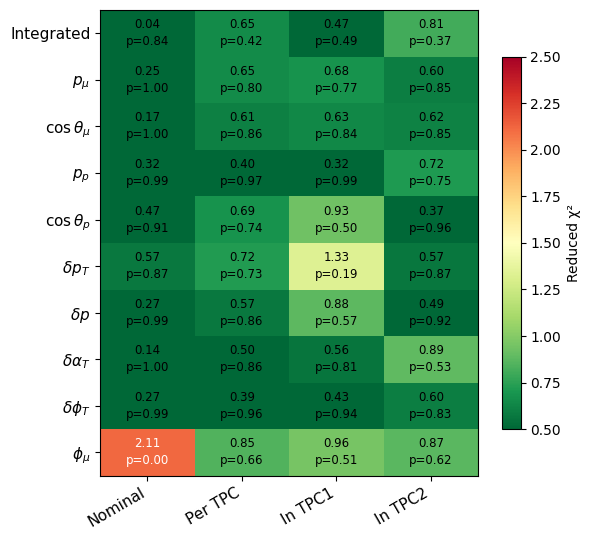

In [10]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sub4 = df.copy()
if chunk_idx is not None:
    sub4 = sub4[sub4["chunk"] == chunk_idx]

sub4["Variable"]     = sub4["var_name"].map(lambda v: VAR_LABELS.get(v, v))
sub4["Cut"]          = sub4["cut_label"].map(lambda c: CUT_LABELS.get(c, c))
sub4["reduced_chi2"] = sub4["chi2"] / sub4["ndof"]

heat = sub4.pivot_table(
    index="Variable", columns="Cut",
    values="reduced_chi2", aggfunc="first"
)
pval_heat = sub4.pivot_table(
    index="Variable", columns="Cut",
    values="p_val", aggfunc="first"
)

present_cuts4 = [c for c in cut_order if c in heat.columns]
var_order4    = [VAR_LABELS.get(v, v) for v in VAR_ORDER_KEYS]
present_vars4 = [v for v in var_order4 if v in heat.index]
heat      = heat.reindex(index=present_vars4, columns=present_cuts4)
pval_heat = pval_heat.reindex(index=present_vars4, columns=present_cuts4)

fig, ax = plt.subplots(figsize=(max(6, len(present_cuts4) * 1.4), max(4, len(present_vars4) * 0.55)))

cmap  = plt.cm.RdYlGn_r
vmin, vmax = 0.5, 2.5
norm  = mcolors.Normalize(vmin=vmin, vmax=vmax)
mat   = heat.values.astype(float)

im = ax.imshow(mat, cmap=cmap, norm=norm, aspect="auto")
plt.colorbar(im, ax=ax, label="Reduced χ²", shrink=0.8)

ax.set_xticks(range(len(present_cuts4)))
ax.set_xticklabels(present_cuts4, rotation=30, ha="right", fontsize=11)
ax.set_yticks(range(len(present_vars4)))
ax.set_yticklabels(present_vars4, fontsize=11)

# Annotate each cell with χ²/ndof and p-value
for i, var in enumerate(present_vars4):
    for j, cut in enumerate(present_cuts4):
        chi2r = heat.loc[var, cut]
        pval  = pval_heat.loc[var, cut]
        if pd.isna(chi2r):
            continue
        bg_lum = norm(chi2r)   # 0 = green (light), 1 = red (dark)
        txt_color = "white" if bg_lum > 0.6 else "black"
        ax.text(j, i, f"{chi2r:.2f}\np={pval:.2f}",
                ha="center", va="center", fontsize=8.5,
                color=txt_color, linespacing=1.4)

# ax.set_title("Reduced χ² heatmap", fontsize=13, pad=10)
plt.tight_layout()
plt.savefig(f"/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/notebooks/chi2_heatmaps/chunk{chunk_idx}.png", bbox_inches="tight", dpi=300)
plt.show()

## Export to CSV

## χ² distribution goodness-of-fit check

Two complementary checks that the χ² values are well-calibrated:

1. **p-value uniformity** — if the test statistic is correctly distributed, p-values should be uniform on [0, 1].  A KS test against a flat distribution is shown.
2. **Wilson–Hilferty normal approximation** — the transform $z = \bigl[(\chi^2/k)^{1/3} - (1 - 2/(9k))\bigr] / \sqrt{2/(9k)}$ maps any $\chi^2_k$ to approximately $\mathcal{N}(0,1)$, regardless of the number of degrees of freedom $k$.  This lets us pool all measurements into a single plot and compare against the standard normal.

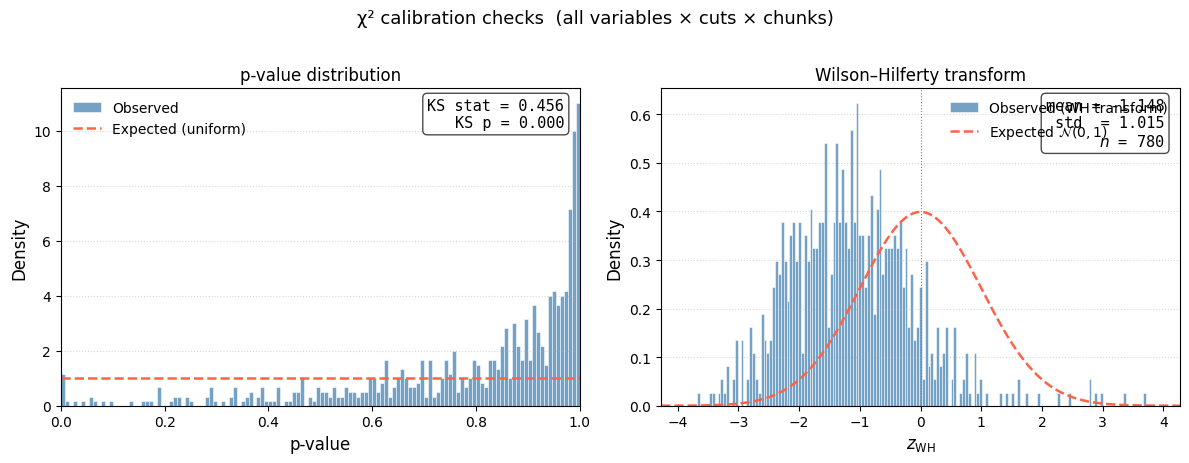

N measurements : 780
p-value  mean  : 0.800  (expected 0.500 for uniform)
WH z     mean  : -1.148  (expected 0.000)
WH z     std   : 1.015  (expected 1.000)
KS test p-value: 0.000  (> 0.05 → consistent with uniform)


In [11]:
from scipy import stats

# ── data ──────────────────────────────────────────────────────────────────────
chi2_vals = df["chi2"].values.astype(float)
ndof_vals = df["ndof"].values.astype(float)
pval_vals = df["p_val"].values.astype(float)

# Wilson–Hilferty transform: chi2_k → approximately N(0,1)
wh_z = ((chi2_vals / ndof_vals) ** (1.0 / 3)
        - (1 - 2.0 / (9 * ndof_vals))) / np.sqrt(2.0 / (9 * ndof_vals))

# ── layout ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("χ² calibration checks  (all variables × cuts × chunks)",
             fontsize=13, y=1.02)

# ── Panel 1: p-value uniformity ───────────────────────────────────────────────
ax = axes[0]
n_bins_p = max(8, len(pval_vals) // 6)
counts, edges, patches = ax.hist(pval_vals, bins=n_bins_p, range=(0, 1),
                                  color="steelblue", alpha=0.75, edgecolor="white",
                                  linewidth=0.5, density=True, label="Observed")

# Expected flat line
ax.axhline(1.0, color="tomato", linewidth=1.8, linestyle="--", label="Expected (uniform)")

# KS test against uniform
ks_stat, ks_pval = stats.kstest(pval_vals, "uniform")
ax.text(0.97, 0.97,
        f"KS stat = {ks_stat:.3f}\nKS p = {ks_pval:.3f}",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=11, family="monospace",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

ax.set_xlim(0, 1)
ax.set_xlabel("p-value", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("p-value distribution", fontsize=12)
ax.legend(fontsize=10, frameon=False)
ax.grid(axis="y", linestyle=":", alpha=0.5)

# ── Panel 2: Wilson–Hilferty transform vs N(0,1) ─────────────────────────────
ax = axes[1]
z_range = max(abs(wh_z.min()), abs(wh_z.max())) * 1.15
z_grid  = np.linspace(-z_range, z_range, 300)

n_bins_z = max(8, len(wh_z) // 5)
ax.hist(wh_z, bins=n_bins_z, density=True,
        color="steelblue", alpha=0.75, edgecolor="white", linewidth=0.5,
        label="Observed (WH transform)")
ax.plot(z_grid, stats.norm.pdf(z_grid),
        color="tomato", linewidth=1.8, linestyle="--", label=r"Expected $\mathcal{N}(0,1)$")

# Annotate sample mean and std
ax.text(0.97, 0.97,
        f"mean = {wh_z.mean():.3f}\nstd  = {wh_z.std():.3f}\n$n$ = {len(wh_z)}",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=11, family="monospace",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

ax.axvline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_xlim(-z_range, z_range)
ax.set_xlabel(r"$z_\mathrm{WH}$", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Wilson–Hilferty transform", fontsize=12)
ax.legend(fontsize=10, frameon=False)
ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

# ── Summary numbers ───────────────────────────────────────────────────────────
print(f"N measurements : {len(df)}")
print(f"p-value  mean  : {pval_vals.mean():.3f}  (expected 0.500 for uniform)")
print(f"WH z     mean  : {wh_z.mean():.3f}  (expected 0.000)")
print(f"WH z     std   : {wh_z.std():.3f}  (expected 1.000)")
print(f"KS test p-value: {ks_pval:.3f}  (> 0.05 → consistent with uniform)")

## Reduced χ² per variable — chunk-by-chunk scatter

Each data point is one chunk. The horizontal bar is the mean across chunks. Reference lines at reduced χ² = 1 (ideal) and 2 (poor fit). One panel per cut selection.

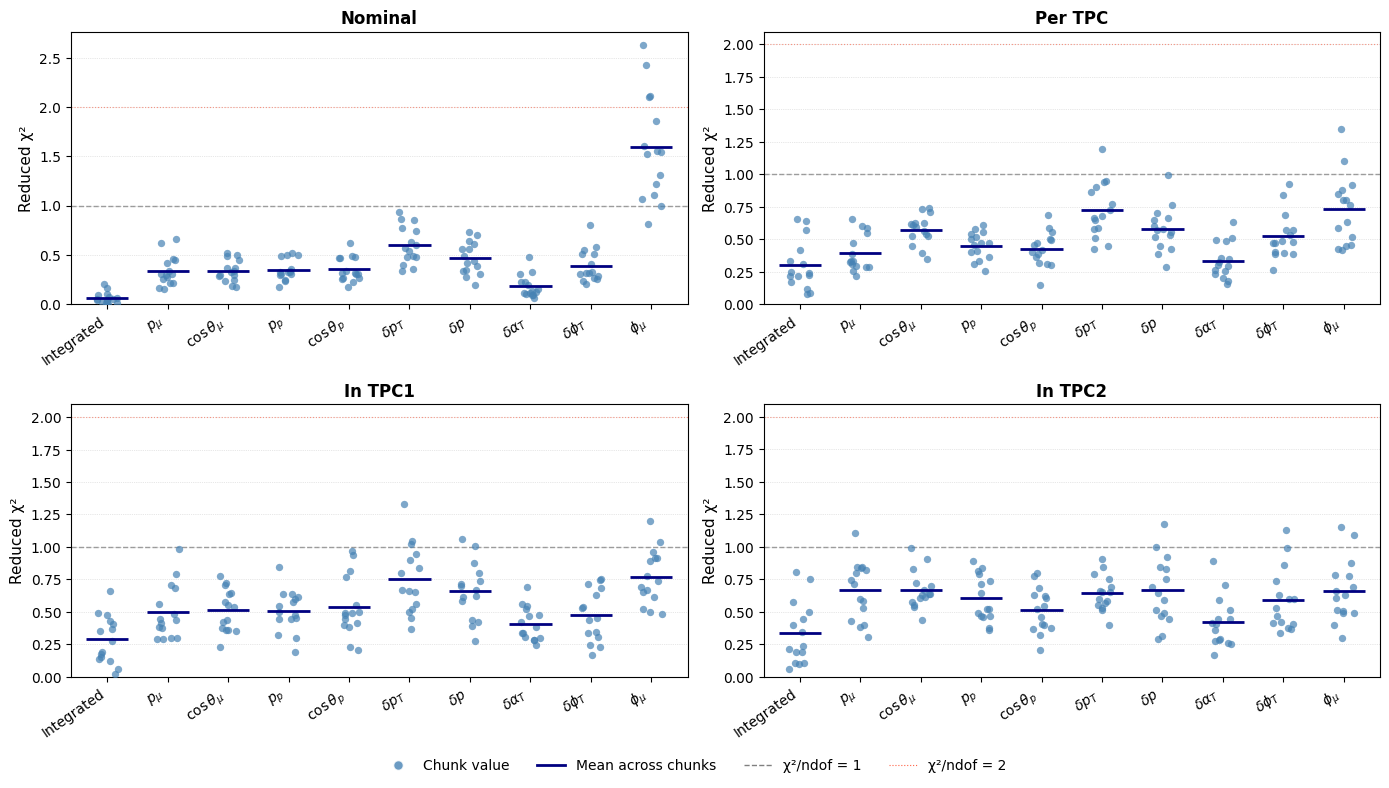

In [ ]:
# ------------------------------
# Optional manual overrides
# ------------------------------
# Use this to patch a specific (variable, cut/TPC-config, chunk) before plotting.
# Keys should use the *raw* `cut_label` values (e.g. "nominal", "perTPC", "inTPC1", "inTPC2", ...).
#
# Example:
# CHI2_CHUNK_OVERRIDES = [
#     {"var_name": "muon_momentum", "cut_label": "perTPC", "chunk": 10, "chi2": 123.4, "ndof": 98, "p_val": 0.12},
# ]
CHI2_CHUNK_OVERRIDES = []


def apply_chi2_overrides(df_in, overrides):
    if not overrides:
        return df_in

    df_out = df_in.copy()
    for ov in overrides:
        v = ov.get("var_name")
        c = ov.get("cut_label")
        k = ov.get("chunk")
        if v is None or c is None or k is None:
            raise ValueError(f"Override must include var_name, cut_label, chunk. Got: {ov}")

        mask = (df_out["var_name"] == v) & (df_out["cut_label"] == c) & (df_out["chunk"] == k)
        n = int(mask.sum())
        if n == 0:
            print(f"[override] WARNING: no match for var={v}, cut_label={c}, chunk={k}")
            continue
        if n > 1:
            print(f"[override] WARNING: {n} matches for var={v}, cut_label={c}, chunk={k}; patching all")

        for col in ["chi2", "ndof", "p_val"]:
            if col in ov and ov[col] is not None:
                df_out.loc[mask, col] = ov[col]

    return df_out


df = apply_chi2_overrides(df, CHI2_CHUNK_OVERRIDES)

# reduced chi2 used for this plot
df["reduced_chi2"] = df["chi2"] / df["ndof"]

df["Variable"]     = df["var_name"].map(lambda v: VAR_LABELS.get(v, v))
df["Cut"]          = df["cut_label"].map(lambda c: CUT_LABELS.get(c, c))

present_cuts_plot = [CUT_LABELS[c] for c in
                     ["nominal", "perTPC", "inTPC1", "inTPC2", "crosser_fwd", "crosser_bwd"]
                     if CUT_LABELS[c] in df["Cut"].unique()]

ncols = 2
nrows = int(np.ceil(len(present_cuts_plot) / ncols))
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 7, nrows * 3.8),
                         sharey=False)
axes = np.array(axes).flatten()

# x-axis tick labels in the canonical variable order
var_tick_labels = [VAR_LABELS.get(v, v) for v in VAR_ORDER_KEYS]

rng = np.random.default_rng(42)   # for jitter

for ax, cut in zip(axes, present_cuts_plot):
    sub = df[df["Cut"] == cut].copy()

    # build x positions from canonical order
    var_list = [v for v in var_tick_labels if v in sub["Variable"].unique()]
    var_pos  = {v: i for i, v in enumerate(var_list)}

    for var, grp in sub.groupby("Variable"):
        if var not in var_pos:
            continue
        x0 = var_pos[var]
        r2 = grp["reduced_chi2"].values
        jitter = rng.uniform(-0.18, 0.18, size=len(r2))

        # individual chunk dots
        ax.scatter(x0 + jitter, r2, s=28, color="steelblue",
                   alpha=0.7, zorder=3, linewidths=0)

        # mean bar
        mean_r2 = r2.mean()
        ax.plot([x0 - 0.35, x0 + 0.35], [mean_r2, mean_r2],
                color="navy", linewidth=2.0, zorder=4, solid_capstyle="butt")

    # reference lines
    ax.axhline(1.0, color="gray",  linewidth=1.0, linestyle="--", alpha=0.8, zorder=1)
    ax.axhline(2.0, color="tomato", linewidth=0.8, linestyle=":",  alpha=0.7, zorder=1)

    ax.set_xticks(range(len(var_list)))
    ax.set_xticklabels(var_list, rotation=35, ha="right", fontsize=10)
    ax.set_xlim(-0.6, len(var_list) - 0.4)
    ax.set_ylabel("Reduced χ²", fontsize=11)
    ax.set_title(cut, fontsize=12, fontweight="bold")
    ax.grid(axis="y", linestyle=":", linewidth=0.5, alpha=0.6)
    ax.set_ylim(bottom=0)

# hide unused panels
for ax in axes[len(present_cuts_plot):]:
    ax.set_visible(False)

# shared legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue",
           markersize=7, alpha=0.8, label="Chunk value"),
    Line2D([0], [0], color="navy", linewidth=2.0, label="Mean across chunks"),
    Line2D([0], [0], color="gray",  linewidth=1.0, linestyle="--", label="χ²/ndof = 1"),
    Line2D([0], [0], color="tomato", linewidth=0.8, linestyle=":",  label="χ²/ndof = 2"),
]
fig.legend(handles=legend_elements, loc="lower center",
           ncol=4, fontsize=10, frameon=False,
           bbox_to_anchor=(0.5, -0.04))

# fig.suptitle("Reduced χ² per variable — each chunk as a data point",
#              fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [9]:
out_csv = f"{base_dir}/{plot_tag}/chi2_summary.csv"
export = df[["chunk", "var_name", "breakdown_type", "cut_label", "chi2", "ndof", "p_val"]].copy()
export["reduced_chi2"] = export["chi2"] / export["ndof"]
export = export.sort_values(["var_name", "cut_label", "chunk"]).reset_index(drop=True)
export.to_csv(out_csv, index=False)
print(f"Saved to {out_csv}")
export

Saved to /exp/sbnd/data/users/munjung/plots/numucc1p0pi/selected_events-data-mup-1e20/chi2_summary.csv


,chunk,var_name,breakdown_type,cut_label,chi2,ndof,p_val,reduced_chi2
0,9,integrated,topology,inTPC1,0.426002,1,0.513957,0.426002
1,10,integrated,topology,inTPC1,0.472281,1,0.491940,0.472281
2,9,integrated,topology,inTPC2,0.187320,1,0.665157,0.187320
3,10,integrated,topology,inTPC2,0.808926,1,0.368438,0.808926
4,9,integrated,topology,nominal,0.046690,1,0.828926,0.046690
...,...,...,...,...,...,...,...,...
99,10,tki-del_phi,topology,inTPC2,6.546927,11,0.834499,0.595175
100,9,tki-del_phi,topology,nominal,4.435138,11,0.955420,0.403194
101,10,tki-del_phi,topology,nominal,2.926338,11,0.991664,0.266031
102,9,tki-del_phi,topology,perTPC,4.227704,11,0.962776,0.384337


# Make GIFs

In [80]:
import os
import imageio.v3 as iio
from PIL import Image
from pathlib import Path

# import argparse
# parser = argparse.ArgumentParser(description="hello")
# parser.add_argument('-i', '--inpath', type=str, default=str(os.getcwd()), help="I will glob all pngs and jpgs from this folder")
# parser.add_argument('-o', '--outpath', type=str, default=str(os.path.join(os.getcwd(), 'hist_evolution')), help='I will make an mp4 and a gif with this name')
# parser.add_argument('-f', '--fps', type=int, default=10, help='How many fps')
# parser.add_argument('--match', type=str, default=None, help='If you give me a match, I will glob all pngs/jpgs matching this string')
# args = parser.parse_args()

def custom_walk(directory):
    for entry in directory.iterdir():
        if entry.is_dir():
            yield from custom_walk(entry)
        else:
            yield entry

def collect_images(image_folder: Path, match=None):
    """Return sorted list of image file paths."""
    images = []
    for filepath in sorted(custom_walk(image_folder)):
        if match and match not in filepath.name:
            continue
        if filepath.suffix.lower() in (".png", ".jpg", ".jpeg"):
            # print(filepath)
            images.append(filepath)
    print(len(images))
    return images


def make_gif(image_paths, output_path="animation.gif", fps=10):
    if not image_paths:
        print("No images found!")
        return
    frames = [Image.fromarray(iio.imread(path)) for path in image_paths]
    frames[0].save(
        output_path,
        format='GIF',
        save_all=True,
        append_images=frames[1:],
        duration=1000 // fps,
        loop=0
    )
    
    print(f"GIF saved to {output_path}")


def make_mp4(image_paths, output_path="animation.mp4", fps=10):
    if not image_paths:
        print("No images found!")
        return
        
    '''
    frames = [iio.imread(path) for path in image_paths]
    iio.imwrite(output_path, frames, fps=fps, codec='libx264')
    '''
    
    with iio.imopen(output_path, "w", plugin="pyav") as writer:
        writer.init_video_stream("libx264", fps=fps)

        for path in image_paths:
            print(path)
            frame = iio.imread(path)[..., :3]
            h, w = frame.shape[:2]
            frame = frame[:h - (h%2),:w - (w%2)]
            writer.write_frame(frame)
    print(f"MP4 saved to {output_path}")

In [87]:
inpath = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi/selected_events-data-mup-1e20-contTPC1"
outpath = "./gifs_contTPC1/"
fps=10
for match in [
              "integrated.png",
              "integrated_chi2",
            #   "muon-p_topology.png",
            #   "muon-dir_z_topology.png",
            #   "proton-p_topology.png",
            #   "proton-dir_z_topology.png",
            #   "tki-del_Tp_topology.png",
            #   "tki-del_p_topology.png",
            #   "tki-del_alpha_topology.png",
            #   "tki-del_phi_topology.png",
            #   "muon-dir_phi_topology.png"
            #   "muon-p_topology_chi2",
            #   "muon-dir_z_topology_chi2",
            #   "proton-p_topology_chi2",
            #   "proton-dir_z_topology_chi2",
            #   "tki-del_Tp_topology_chi2",
            #   "tki-del_p_topology_chi2",
            #   "tki-del_alpha_topology_chi2",
            #   "tki-del_phi_topology_chi2",
            #   "muon-dir_phi_topology_chi2"
]:

    folder = Path(inpath)
    image_list = collect_images(folder, match)

    make_gif(image_list, output_path=outpath + match + ".gif", fps=fps)
    # make_mp4(image_list, output_path=outpath + ".mp4", fps=fps)

0
No images found!
0
No images found!


In [83]:
inpath = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi/selected_events-data-mup-1e20-contTPC2"
outpath = "./gifs_contTPC2/"
fps=10
for match in [
              "muon-p_topology.png",
              "muon-dir_z_topology.png",
              "proton-p_topology.png",
              "proton-dir_z_topology.png",
              "tki-del_Tp_topology.png",
              "tki-del_p_topology.png",
              "tki-del_alpha_topology.png",
              "tki-del_phi_topology.png",
              "muon-dir_phi_topology.png"
              "muon-p_topology_chi2",
              "muon-dir_z_topology_chi2",
              "proton-p_topology_chi2",
              "proton-dir_z_topology_chi2",
              "tki-del_Tp_topology_chi2",
              "tki-del_p_topology_chi2",
              "tki-del_alpha_topology_chi2",
              "tki-del_phi_topology_chi2",
              "muon-dir_phi_topology_chi2"
]:

    folder = Path(inpath)
    image_list = collect_images(folder, match)

    make_gif(image_list, output_path=outpath + match + ".gif", fps=fps)
    # make_mp4(image_list, output_path=outpath + ".mp4", fps=fps)

15
GIF saved to ./gifs_contTPC2/muon-p_topology.png.gif
15
GIF saved to ./gifs_contTPC2/muon-dir_z_topology.png.gif
15
GIF saved to ./gifs_contTPC2/proton-p_topology.png.gif
15
GIF saved to ./gifs_contTPC2/proton-dir_z_topology.png.gif
15
GIF saved to ./gifs_contTPC2/tki-del_Tp_topology.png.gif
15
GIF saved to ./gifs_contTPC2/tki-del_p_topology.png.gif
15
GIF saved to ./gifs_contTPC2/tki-del_alpha_topology.png.gif
15
GIF saved to ./gifs_contTPC2/tki-del_phi_topology.png.gif
0
No images found!
15
GIF saved to ./gifs_contTPC2/muon-dir_z_topology_chi2.gif
15
GIF saved to ./gifs_contTPC2/proton-p_topology_chi2.gif
15
GIF saved to ./gifs_contTPC2/proton-dir_z_topology_chi2.gif
15
GIF saved to ./gifs_contTPC2/tki-del_Tp_topology_chi2.gif
15
GIF saved to ./gifs_contTPC2/tki-del_p_topology_chi2.gif
15
GIF saved to ./gifs_contTPC2/tki-del_alpha_topology_chi2.gif
15
GIF saved to ./gifs_contTPC2/tki-del_phi_topology_chi2.gif
15
GIF saved to ./gifs_contTPC2/muon-dir_phi_topology_chi2.gif


In [85]:
inpath = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi/selected_events-data-mup-1e20-perTPC"
outpath = "./gifs_perTPC/"
fps=10
for match in [
              "muon-p_topology.png",
              "muon-dir_z_topology.png",
              "proton-p_topology.png",
              "proton-dir_z_topology.png",
              "tki-del_Tp_topology.png",
              "tki-del_p_topology.png",
              "tki-del_alpha_topology.png",
              "tki-del_phi_topology.png",
              "muon-dir_phi_topology.png"
              "muon-p_topology_chi2",
              "muon-dir_z_topology_chi2",
              "proton-p_topology_chi2",
              "proton-dir_z_topology_chi2",
              "tki-del_Tp_topology_chi2",
              "tki-del_p_topology_chi2",
              "tki-del_alpha_topology_chi2",
              "tki-del_phi_topology_chi2",
              "muon-dir_phi_topology_chi2"
]:

    folder = Path(inpath)
    image_list = collect_images(folder, match)

    make_gif(image_list, output_path=outpath + match + ".gif", fps=fps)
    # make_mp4(image_list, output_path=outpath + ".mp4", fps=fps)

15
GIF saved to ./gifs_perTPC/muon-p_topology.png.gif
15
GIF saved to ./gifs_perTPC/muon-dir_z_topology.png.gif
15
GIF saved to ./gifs_perTPC/proton-p_topology.png.gif
15
GIF saved to ./gifs_perTPC/proton-dir_z_topology.png.gif
15
GIF saved to ./gifs_perTPC/tki-del_Tp_topology.png.gif
15
GIF saved to ./gifs_perTPC/tki-del_p_topology.png.gif
15
GIF saved to ./gifs_perTPC/tki-del_alpha_topology.png.gif
15
GIF saved to ./gifs_perTPC/tki-del_phi_topology.png.gif
0
No images found!
15
GIF saved to ./gifs_perTPC/muon-dir_z_topology_chi2.gif
15
GIF saved to ./gifs_perTPC/proton-p_topology_chi2.gif
15
GIF saved to ./gifs_perTPC/proton-dir_z_topology_chi2.gif
15
GIF saved to ./gifs_perTPC/tki-del_Tp_topology_chi2.gif
15
GIF saved to ./gifs_perTPC/tki-del_p_topology_chi2.gif
15
GIF saved to ./gifs_perTPC/tki-del_alpha_topology_chi2.gif
15
GIF saved to ./gifs_perTPC/tki-del_phi_topology_chi2.gif
15
GIF saved to ./gifs_perTPC/muon-dir_phi_topology_chi2.gif


In [86]:
inpath = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi/selected_events-data-mup-1e20"
outpath = "./gifs_nominal/"
fps=10
for match in [
              "muon-p_topology.png",
              "muon-dir_z_topology.png",
              "proton-p_topology.png",
              "proton-dir_z_topology.png",
              "tki-del_Tp_topology.png",
              "tki-del_p_topology.png",
              "tki-del_alpha_topology.png",
              "tki-del_phi_topology.png",
              "muon-dir_phi_topology.png"
              "muon-p_topology_chi2",
              "muon-dir_z_topology_chi2",
              "proton-p_topology_chi2",
              "proton-dir_z_topology_chi2",
              "tki-del_Tp_topology_chi2",
              "tki-del_p_topology_chi2",
              "tki-del_alpha_topology_chi2",
              "tki-del_phi_topology_chi2",
              "muon-dir_phi_topology_chi2"
]:

    folder = Path(inpath)
    image_list = collect_images(folder, match)

    make_gif(image_list, output_path=outpath + match + ".gif", fps=fps)
    # make_mp4(image_list, output_path=outpath + ".mp4", fps=fps)

15
GIF saved to ./gifs_nominal/muon-p_topology.png.gif
15
GIF saved to ./gifs_nominal/muon-dir_z_topology.png.gif
15
GIF saved to ./gifs_nominal/proton-p_topology.png.gif
15
GIF saved to ./gifs_nominal/proton-dir_z_topology.png.gif
15
GIF saved to ./gifs_nominal/tki-del_Tp_topology.png.gif
15
GIF saved to ./gifs_nominal/tki-del_p_topology.png.gif
15
GIF saved to ./gifs_nominal/tki-del_alpha_topology.png.gif
15
GIF saved to ./gifs_nominal/tki-del_phi_topology.png.gif
0
No images found!
15
GIF saved to ./gifs_nominal/muon-dir_z_topology_chi2.gif
15
GIF saved to ./gifs_nominal/proton-p_topology_chi2.gif
15
GIF saved to ./gifs_nominal/proton-dir_z_topology_chi2.gif
15
GIF saved to ./gifs_nominal/tki-del_Tp_topology_chi2.gif
15
GIF saved to ./gifs_nominal/tki-del_p_topology_chi2.gif
15
GIF saved to ./gifs_nominal/tki-del_alpha_topology_chi2.gif
15
GIF saved to ./gifs_nominal/tki-del_phi_topology_chi2.gif
15
GIF saved to ./gifs_nominal/muon-dir_phi_topology_chi2.gif
